# Assignment 1, Task B: Regression using tree methods.

## The data:
In this QSAR exercise, water solubility of various molecules is to be investigated. The dataset in use is the ESOL Dataset assembled by John Delaney, as provided here: https://huggingface.co/datasets/scikit-fingerprints/MoleculeNet_ESOL/tree/main.


## The tasks:
1) Inspect the data and clean if needed. Adhere to good practices!
2) Calculate some molecular descriptors via the smiles strings using rdkit (partial snippet provided)
3) Create a feature matrix X and a target vector y
4) Three different models should be trained on the molecular descriptors and evaluated according to RMSE and their R2 score to compare their performance. For each model, additionally, the overfitting needs to be addressed.

These three models have to be compared:
- `DecisionTreeRegressor`
- `RandomForestRegressor`
- `GradientBoostingRegressor`

For a first baseline performance, the models can be used as provided by `scikit`, but should include a random seed. 

5) Based on the model performance, take the best performing algorithm and optimise its hyperparameters using `GridSearchCV`

6) Assess the feature importance

7) Conclusion and discussion: Provide answers to the questions.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("esol.csv")
df.head()

,SMILES,label
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


## 1. Inspect and clean the data
Gain some overview of the data and assess NaNs and duplicates and clean if needed.

In [3]:
df.info() # no dropNa needed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  1128 non-null   object 
 1   label   1128 non-null   float64
dtypes: float64(1), object(1)
memory usage: 17.8+ KB


In [ ]:
df.duplicated().sum() # no dulicates -> data is clean

np.int64(0)

## 2. Create molecular descriptors from the Smiles
Use the snippet below to calculate descriptors from the SMILES strings. Make sure to include the molecular weight, the logP and choose three more which you believe to impact the solubility, e.g. https://greglandrum.github.io/rdkit-blog/posts/2022-12-23-descriptor-tutorial.html or here: https://deepwiki.com/rdkit/rdkit/6.1-molecular-descriptors-and-properties 

In [7]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),           # polarity / polar surface area
        "HBD": Descriptors.NumHDonors(mol),      # H-bond donors
        "HBA": Descriptors.NumHAcceptors(mol),   # H-bond acceptors

    })

# Apply to dataframe
descriptor_df = df["SMILES"].apply(compute_descriptors)

# Combine descriptors with original data
df_full = pd.concat([df, descriptor_df], axis=1)

# Remove rows where descriptor calculation failed
df_full = df_full.dropna()
df_full.head()

,SMILES,label,MolWt,LogP,TPSA,HBD,HBA
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,202.32,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,42.24,1.0,2.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,17.07,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,0.00,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.00,0.0,1.0


In [12]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  1128 non-null   object 
 1   label   1128 non-null   float64
 2   MolWt   1128 non-null   float64
 3   LogP    1128 non-null   float64
 4   TPSA    1128 non-null   float64
 5   HBD     1128 non-null   float64
 6   HBA     1128 non-null   float64
dtypes: float64(6), object(1)
memory usage: 61.8+ KB


## 3. Create the feature matrix and target vector

In [13]:
feature_cols = ["MolWt", "LogP", "TPSA", "HBD", "HBA"]

X = df_full[feature_cols]
y = df_full["label"]

X = X.values
y = y.values

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (1128, 5)
Target vector shape: (1128,)


## 4. Train the models
Use a classic train-test split of 0.2 including a random seed. For training and predicting labels, take note of the time the process takes for each model (does not necessarily have to be coded, can also be estimated). Make sure to predict labels for both training and test splits in order to identify overfitting. Use the RMSE and R2 as metrics for evaluation of the baseline performance of the models. Make sure to consider overfitting.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    #random_state=42,
    #stratify=y
)

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    
    # Measure training time
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_RMSE = mean_squared_error(y_train, y_train_pred)
    test_RMSE = mean_squared_error(y_test, y_test_pred)

    rmse_gap = test_RMSE - train_RMSE
    r2_gap = train_r2 - test_r2

    # Print results
    """
    print(name)
    print(f"  Train R2: {train_r2:.3f}")
    print(f"  Test  R2: {test_r2:.3f}")
    print(f"  R2 Gap (train-test): {r2_gap:.3f}")
    print(f"  Train RMSE:  {train_RMSE:.3f}")
    print(f"  Test  RMSE:  {test_RMSE:.3f}")
    print(f"  RMSE Gap (train-test): {rmse_gap:.3f}")
    print(f"  Training Time:  {train_time:.3f} seconds")
    print("-" * 40)
    """
    # Scatter plot
    plt.figure()
    plt.scatter(y_test, y_test_pred)

    # Ideal diagonal line
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("True Values (y_test)")
    plt.ylabel("Predicted Values (y_pred)")
    plt.title( f"{name}: True vs Predicted Solubility")

    plt.show()

    return {
        "Model": name,
        "Train RMSE": train_RMSE,
        "Test RMSE": test_RMSE,
        "RMSE Gap": rmse_gap,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "R2 Gap": r2_gap,
        "Train Time (s)": train_time,
    }


In [44]:
models = [
    ("DecisionTree", DecisionTreeRegressor(random_state=42)),
    ("RandomForest", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),
    ("GradientBoosting", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
]

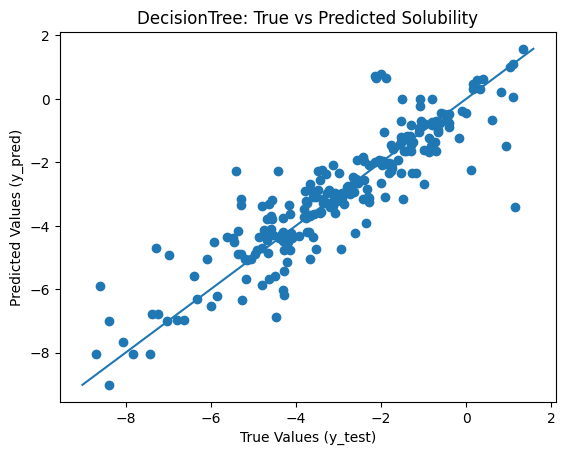

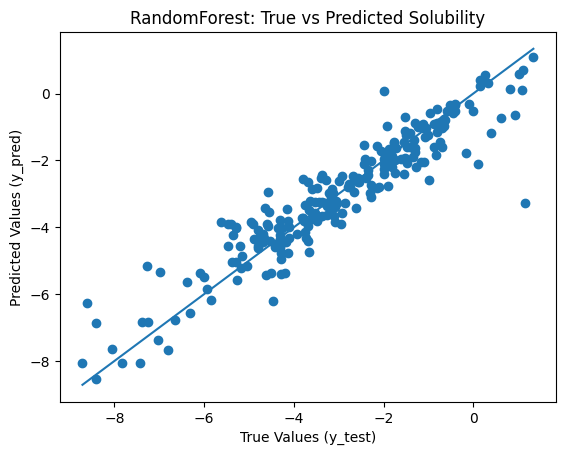

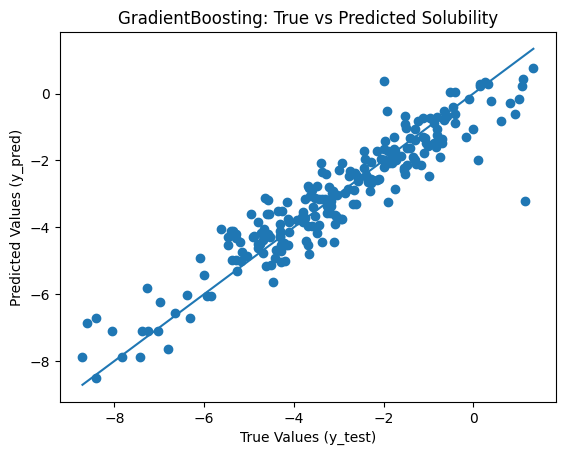

,Model,Train RMSE,Test RMSE,RMSE Gap,Train R2,Test R2,R2 Gap,Train Time (s)
2,GradientBoosting,0.257814,0.550316,0.292502,0.941711,0.870940,0.070771,0.322818
1,RandomForest,0.085520,0.551035,0.465515,0.980665,0.870771,0.109893,0.344218
0,DecisionTree,0.019474,0.895879,0.876405,0.995597,0.789899,0.205698,0.007817


In [48]:
results = []

for name, model in models:
    results.append(
        evaluate_model(name, model, X_train, X_test, y_train, y_test)
    )

results_df = pd.DataFrame(results).sort_values("Test RMSE")
results_df

Use the best model and plot the predictions over the true values (y_test vs. y_pred) in a scatterplot.

See above for plots \
Best model is Gradiant Boosting since it has the lowest RMSE in the Test, lowest RMSE Gap \
also it has the highest R2 in the Test as well as the smallest R2 Gap

## 5. Hyperparameter tuning of the best model
Use GridSearchCV to optimise the hyperparameters for the best model. Use a reasonable parameter grid (2-3 different values max. for each parameter you want to optimise).

In [59]:
param_grid = {
    "n_estimators": [50, 100, 300,],      
    "learning_rate": [0.1, 0.2, 0.3],    
    "max_depth": [2, 4, 6],               
    "min_samples_split": [5, 10, 15],       
    "min_samples_leaf": [2, 4, 6]
}

In [60]:
grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)



Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.2, ...], 'max_depth': [2, 4, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

Extract the best model

In [61]:
best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


Useful tool: Export (and reimport) your best model:

In [62]:
import joblib
# export the best model:
joblib.dump(best_model, "best_model.joblib")
# reload the best model:
loaded_model = joblib.load("best_model.joblib")

Evaluate the best model on the test set.

In [63]:
# Predict using the loaded model
y_test_pred = loaded_model.predict(X_test)

# Compute metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Evaluation of Reloaded Best Model (Test Set)")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test R²:   {test_r2:.3f}")

Evaluation of Reloaded Best Model (Test Set)
Test RMSE: 0.741
Test R²:   0.871


Plot the predicted vs. the true solubility again!

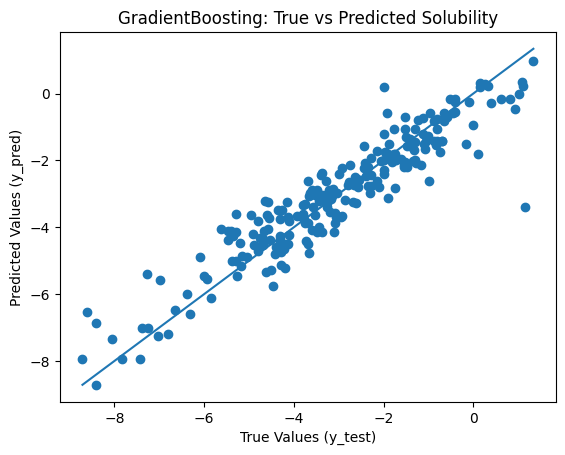

In [65]:
# Scatter plot
plt.figure()
plt.scatter(y_test, y_test_pred)

# Ideal diagonal line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title( f"{name}: True vs Predicted Solubility")

plt.show()

## 6. Feature importance
Investigate the feature importance for your best model using the snippet below (but with your descriptors).

In [66]:
feature_names = [
    "MolWt", "LogP" , "TPSA", "HBD", "HBA"
]

importances = best_model.feature_importances_

for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

LogP: 0.847
MolWt: 0.089
TPSA: 0.048
HBA: 0.012
HBD: 0.004


## 7. Conclusion and discussion
- Which model performed the best?
- Which model showed the worst overfitting?
- Did the GridSearchCV improve the model? Is the difference to be considered significant?
- Which descriptors (besides the logP) had the most influence on the solubility?



Which modle perfomed the best? 
- GradientBoostingRegressor
    - Lowest Test RMSE: 0.550
    - Highest Test R²: 0.871
    - Smallest generalization gap (R² gap = 0.071)

Which modle showed the worst overfitting?
- DecisionTreeRegressor
    - Train RMSE: 0.019 vs Test RMSE: 0.896
    - large RMSE gap: 0.876
    - Classic high-variance overfitting behavior.

Did the GridSearchCV improve the model? Is the difference to be considered significant?
- not very much so R2 slightly improved and RMSE increased slightly
- no it's not sigificant 

Which descriptors (besides the logP) had the most influence on the solubility?
- the ones I choose had a minimal effect 
- the highest (besides the logP) was MolWt